In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

In [ ]:
df_tm = pd.read_csv("../data/dataset_topomap_5seg.csv")
df_tm = df_tm.rename(columns={'file_path': 'path', 'Affective disorder': 'label'})

print(df_tm.columns)
print(df_tm['label'].value_counts())

Index(['REC_ID', 'segment', 'band', 'path', 'label'], dtype='object')
label
1    1750
0    1750
Name: count, dtype: int64


In [3]:
band_order = ["delta", "theta", "alpha", "beta", "gamma"]
df_tm["band"] = pd.Categorical(df_tm["band"], categories=band_order,ordered=True)
df_tm = df_tm.sort_values(["REC_ID", "band"]).reset_index(drop=True)

In [4]:
def build_subject_segment_df(df):
    subjects = []

    for (sid, seg), group in df.groupby(["REC_ID", "segment"]):
        group = group.set_index("band").reindex(band_order)

        if group["path"].isnull().any():
            continue

        subjects.append({
            "REC_ID": sid,
            "segment": seg,
            "paths": group["path"].tolist(),
            "label": group["label"].iloc[0]
        })
    return pd.DataFrame(subjects)

In [5]:
class EEGImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        images = []

        for path in row["paths"]:
            img = Image.open(path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            images.append(img)
        images = torch.stack(images)
        label = torch.tensor(row["label"], dtype=torch.long)
        return images, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

In [7]:
subject_segment_df = build_subject_segment_df(df_tm)
subject_labels = subject_segment_df.groupby("REC_ID")["label"].first()
subject_to_label = dict(zip(subject_labels.index, subject_labels.values))
subject_segment_df["subject_label_for_stratification"] = subject_segment_df["REC_ID"].map(subject_to_label)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, temp_idx = next(
    sgkf.split(
        X=subject_segment_df,
        y=subject_segment_df["subject_label_for_stratification"],
        groups=subject_segment_df["REC_ID"]
    )
)
train_df_tm = subject_segment_df.iloc[train_idx].reset_index(drop=True)
temp_df_tm  = subject_segment_df.iloc[temp_idx].reset_index(drop=True)

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

val_idx, test_idx = next(
    sgkf2.split(
        X=temp_df_tm,
        y=temp_df_tm["subject_label_for_stratification"],
        groups=temp_df_tm["REC_ID"]
    )
)
val_df_tm  = temp_df_tm.iloc[val_idx].reset_index(drop=True)
test_df_tm = temp_df_tm.iloc[test_idx].reset_index(drop=True)

train_subjects = set(train_df_tm["REC_ID"])
val_subjects   = set(val_df_tm["REC_ID"])
test_subjects  = set(test_df_tm["REC_ID"])

print("Train ∩ Val:", train_subjects & val_subjects)
print("Train ∩ Test:", train_subjects & test_subjects)
print("Val ∩ Test:", val_subjects & test_subjects)

print("\nTRAIN:")
print(train_df_tm["label"].value_counts())
print("\nVALIDATION:")
print(val_df_tm["label"].value_counts())
print("\nTEST:")
print(test_df_tm["label"].value_counts())

test_df_tm.head(20)

Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()

TRAIN:
label
1    280
0    280
Name: count, dtype: int64

VALIDATION:
label
0    40
1    30
Name: count, dtype: int64

TEST:
label
1    40
0    30
Name: count, dtype: int64


,REC_ID,segment,paths,label,subject_label_for_stratification
0,4002,1,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
1,4002,2,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
2,4002,3,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
3,4002,4,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
4,4002,5,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
5,4054,1,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
6,4054,2,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
7,4054,3,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
8,4054,4,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1
9,4054,5,[C:\Users\Lucija\Documents\Lucija\faks\diploms...,1,1


In [8]:
print(df_tm.groupby("REC_ID").size().value_counts())

25    140
Name: count, dtype: int64


In [9]:
train_dataset_tm = EEGImageDataset(train_df_tm, transform)
val_dataset_tm   = EEGImageDataset(val_df_tm, transform)
test_dataset_tm  = EEGImageDataset(test_df_tm, transform)

train_loader_tm = DataLoader(train_dataset_tm, batch_size=8, shuffle=True)
val_loader_tm   = DataLoader(val_dataset_tm, batch_size=8, shuffle=False)
test_loader_tm  = DataLoader(test_dataset_tm, batch_size=8, shuffle=False)

In [10]:
x, y = next(iter(train_loader_tm))
print(x.shape)
print(y[:5])

torch.Size([8, 5, 3, 256, 256])
tensor([0, 1, 1, 1, 1])


In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = []
        self.activations = []

        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations.append(output.detach().clone())

        def backward_hook(module, grad_input, grad_output):
            grad = grad_output[0].detach().clone()
            self.gradients.append(grad)

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        self.activations = []
        self.gradients = []

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[:, target_class].sum()
        loss.backward()

        if len(self.activations) != len(self.gradients):
            raise RuntimeError(f"GradCAM collected mismatched activations ({len(self.activations)}) and gradients ({len(self.gradients)})")

        cams = []
        for act, grad in zip(self.activations, self.gradients):
            if grad.ndim == 3:
                grad = grad.unsqueeze(0)
            if act.ndim == 3:
                act = act.unsqueeze(0)
            
            weights = grad.mean(dim=(2, 3), keepdim=True)
            
            cam = torch.sum(weights * act, dim=1)
            cam = torch.relu(cam)
            cam = cam[0].cpu().numpy()
            cam -= cam.min()
            cam /= (cam.max() + 1e-10)
            cams.append(cam)
        return cams, target_class

In [12]:
class SimpleEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.flatten_dim = 64 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim * 5, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        B, bands, C, H, W = x.shape
        features = []

        for i in range(bands):
            xi = x[:, i]
            fi = self.feature_extractor(xi)
            fi = fi.view(B, -1)
            features.append(fi)

        x = torch.cat(features, dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = SimpleEEGCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

cpu


In [14]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        assert x.ndim == 5, f"Expected [B, 5, 3, 256, 256], got {x.shape}"

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(loader)
    acc = correct / total
    return avg_loss, acc

In [15]:
def eval_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = correct / total

    return avg_loss, acc, all_labels, all_preds

Epoch 01 | train_loss=1.2113 | train_acc=0.655 | val_loss=0.4980 | val_acc=0.743
Epoch 02 | train_loss=0.3095 | train_acc=0.891 | val_loss=0.6701 | val_acc=0.743
Epoch 03 | train_loss=0.2259 | train_acc=0.902 | val_loss=0.7806 | val_acc=0.700
Epoch 04 | train_loss=0.1463 | train_acc=0.932 | val_loss=1.0325 | val_acc=0.686
Epoch 05 | train_loss=0.1173 | train_acc=0.957 | val_loss=1.1717 | val_acc=0.643
Epoch 06 | train_loss=0.0609 | train_acc=0.975 | val_loss=1.1596 | val_acc=0.686
Epoch 07 | train_loss=0.0900 | train_acc=0.968 | val_loss=1.1201 | val_acc=0.671
Epoch 08 | train_loss=0.0456 | train_acc=0.986 | val_loss=1.3839 | val_acc=0.729
Epoch 09 | train_loss=0.0272 | train_acc=0.991 | val_loss=1.6146 | val_acc=0.657
Epoch 10 | train_loss=0.0128 | train_acc=0.993 | val_loss=2.2998 | val_acc=0.686
Epoch 11 | train_loss=0.0067 | train_acc=0.998 | val_loss=2.7034 | val_acc=0.643
Epoch 12 | train_loss=0.1476 | train_acc=0.955 | val_loss=1.1514 | val_acc=0.700
Epoch 13 | train_loss=0.0274

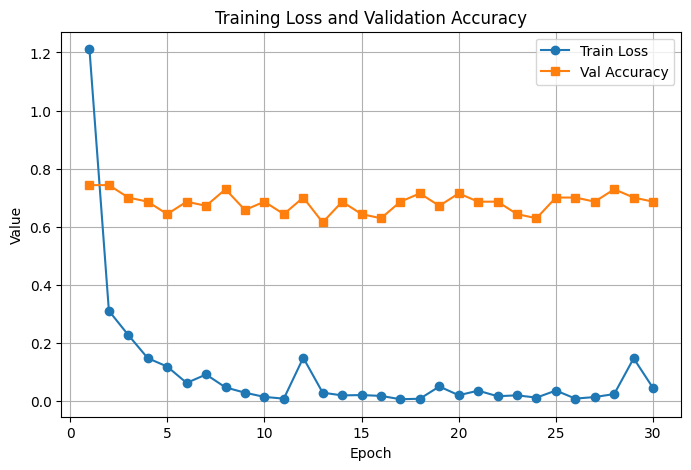

In [16]:
num_epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses_tm = []
train_accs_tm = []
val_losses_tm = []
val_accs_tm = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader_tm, optimizer, criterion, device)
    val_loss, val_acc, y_true, y_pred = eval_epoch(model, val_loader_tm, criterion, device)

    train_losses_tm.append(train_loss)
    train_accs_tm.append(train_acc)

    val_losses_tm.append(val_loss)
    val_accs_tm.append(val_acc)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.3f} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")
    
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_tm, marker='o', label='Train Loss')
plt.plot(epochs, val_accs_tm, marker='s', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
model.eval()
y_true_tm = []
y_pred_tm = []

with torch.no_grad():
    for x, y in test_loader_tm:
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        y_pred_tm.extend(preds.cpu().numpy())
        y_true_tm.extend(y.cpu().numpy())

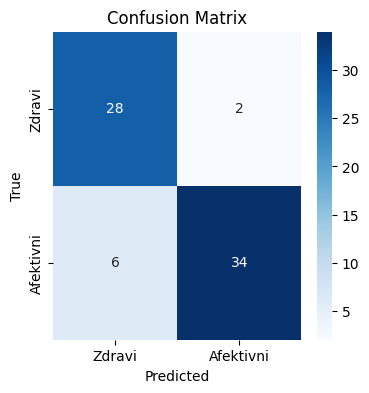

              precision    recall  f1-score   support

      Zdravi       0.82      0.93      0.88        30
   Afektivni       0.94      0.85      0.89        40

    accuracy                           0.89        70
   macro avg       0.88      0.89      0.88        70
weighted avg       0.89      0.89      0.89        70


Accuracy iznosi = 0.8857
F1-score iznosi = 0.8947


In [18]:
cm = confusion_matrix(y_true_tm, y_pred_tm)

plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Zdravi', 'Afektivni'],
    yticklabels=['Zdravi', 'Afektivni']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(
    classification_report(
        y_true_tm,
        y_pred_tm,
        target_names=['Zdravi', 'Afektivni']
    )
)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

print(f"\nAccuracy iznosi = {accuracy:.4f}")
print(f"F1-score iznosi = {f1:.4f}")

In [ ]:
def show_subject_gradcam_publication(subject_id, segment, dataframe, model, gradcam, transform, device):
    subject_df = dataframe[(dataframe['REC_ID'] == subject_id) & (dataframe['segment'] == segment)].reset_index(drop=True)
    n_bands = len(subject_df)

    model.eval()

    images = []
    true_labels = []
    bands = []
    original_images = []

    for _, row in subject_df.iterrows():
        image_pil = Image.open(row['path']).convert('RGB')
        original_images.append(image_pil)
        tensor = transform(image_pil)

        images.append(tensor)
        true_labels.append(row['label'])
        bands.append(row['band'])

    input_tensor = torch.stack(images).unsqueeze(0).to(device)
    cams, pred_class = gradcam.generate_cam(input_tensor)
    fig, axes = plt.subplots(2, n_bands, figsize=(4 * n_bands, 8))

    if n_bands == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(n_bands):
        img_np = np.array(original_images[i]).astype(np.float32) / 255.0

        axes[0, i].imshow(img_np)
        axes[0, i].set_title(f"{bands[i]}", fontsize=10)
        axes[0, i].axis('off')

    for i in range(n_bands):
        img_np = np.array(original_images[i]).astype(np.float32) / 255.0

        heatmap = cams[i]
        heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))

        gray = np.mean(img_np, axis=2)

        axes[1, i].imshow(gray, cmap='gray')

        white_mask = np.all(img_np > 0.95, axis=2)
        cam_overlay = np.ma.masked_where(heatmap < 0.2, heatmap)
        cam_overlay = np.ma.masked_where(white_mask, cam_overlay)

        axes[1, i].imshow(cam_overlay, cmap='jet', alpha=0.55)
        axes[1, i].axis('off')
        
    pred_text = 'Afektivni' if pred_class == 1 else 'Zdravi'
    true_text = 'Afektivni' if true_labels[0] == 1 else 'Zdravi'

    fig.suptitle(
        f"True: {true_text} | Pred: {pred_text}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

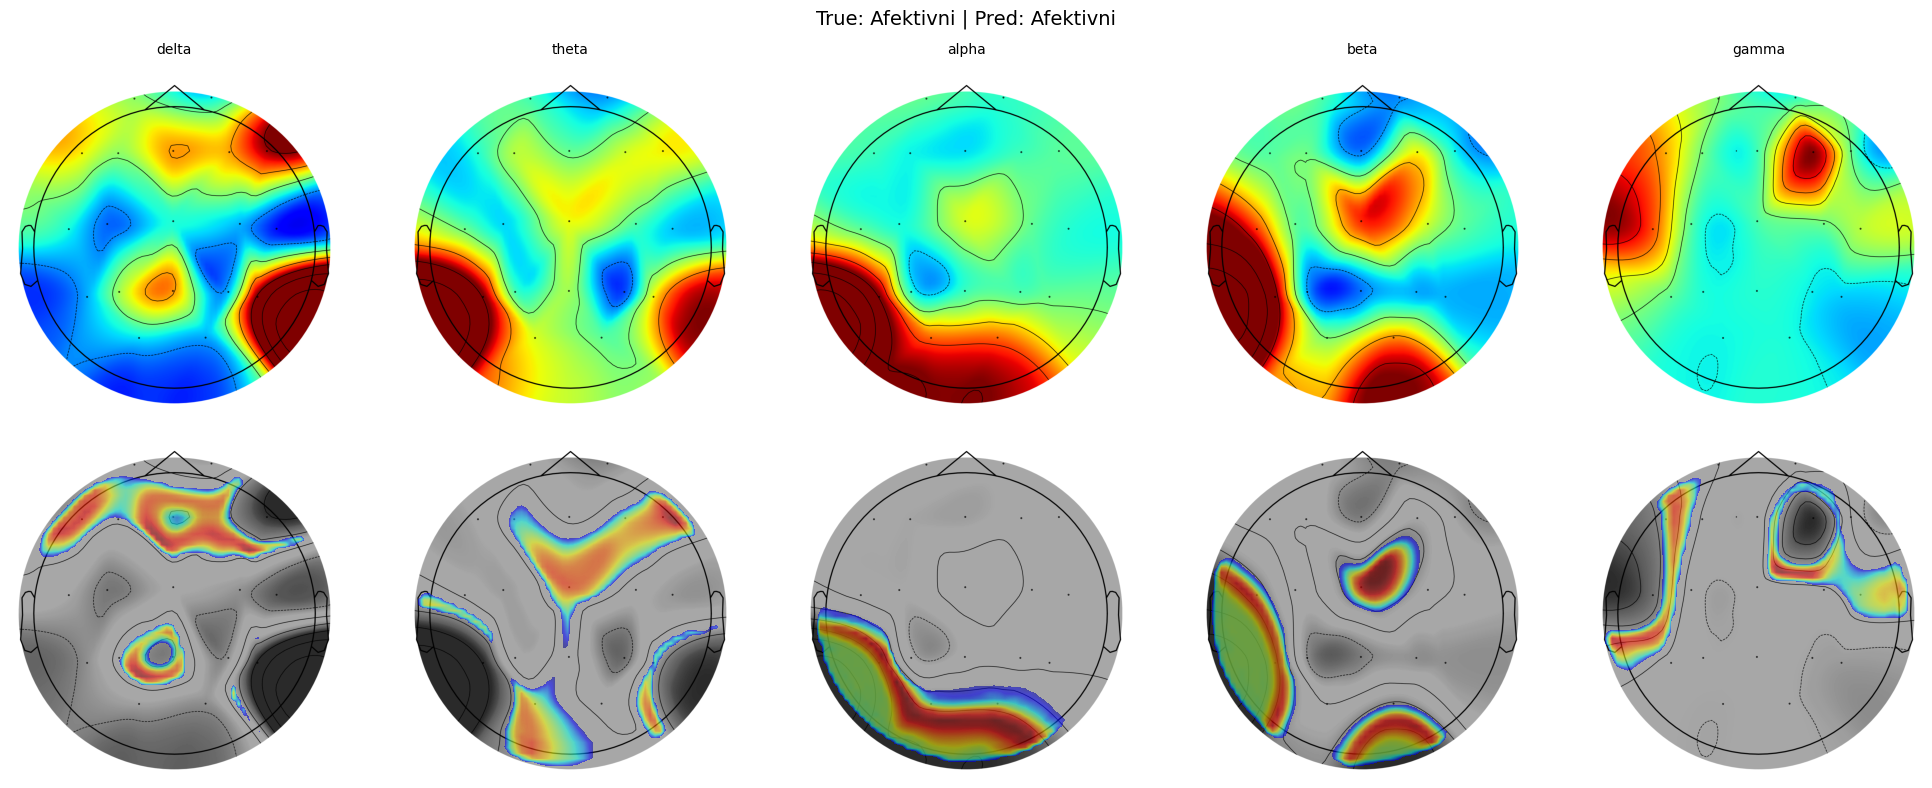

In [20]:
gradcam = GradCAM(model=model, target_layer=model.feature_extractor[6])

show_subject_gradcam_publication(
    subject_id='4002',
    segment=1,
    dataframe=df_tm,
    model=model,
    gradcam=gradcam,
    transform=transform,
    device=device
)